In [20]:
import matplotlib.pyplot as plt
import numpy as np
from Tracer import PGA, WindField
import Tracer.debug_tools as d
import time

In [4]:
# time decorator to measure execution time of functions
def timeit(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        print(f"{func.__name__} took {end_time - start_time:.4f} seconds")
        return result
    return wrapper

In [ ]:
from Tracer.windfield import WindField
from Tracer.fluctuator import Fluctuator
import numpy as np
from scipy.integrate import solve_ivp
from Tracer.solvers import acc, odesystem, hit_ground

def solver_rk45(V0, W0, wind: WindField, fluc: Fluctuator=None, P0=np.zeros(3), dt=0.05, decay_rate=0.05, mt=15, rtol=1e-6):
    y0 = np.concatenate([P0, V0])

    t_requested = np.arange(0, mt + dt, dt) if dt else None

    sol = solve_ivp(
        odesystem, 
        t_span=(0, mt),       # Max time 15 seconds
        y0=y0, 
        method='RK45',        # Dormand-Prince adaptive solver
        args=(W0, wind, fluc, decay_rate),
        events=hit_ground,    # Stops the moment Z hits 0
        t_eval=t_requested,
        rtol=rtol, atol=rtol/1000  # Precision settings
    )

    # Accessing results:
    positions = sol.y[:3, :].T # Shape (N, 3)

    return positions[-1], sol.nfev

def solver_euler(V0, W0, wind: WindField, fluc: Fluctuator=None, P0=np.zeros(3), dt=0.01, decay_rate=0.05):
    # This function will solve the equations of motion for the ball given the initial conditions and parameters
    # It will return the trajectory of the ball as a function of time
    t = [0]
    P = [P0] # position array
    V = [V0]
    W = [W0] # initial angular velocity (rad/s)

    while P[-1][2] >= 0: # while the ball is above the ground
        
        p = P[-1]
        wind_vec, tke, eps = wind.get_profile_at(*p)  # Get local wind velocity vector
        
        if np.isnan(wind_vec).any():
            print(f"Warning: NaN in wind at position {p.round(3)}. Setting wind to zero.")
            wind_vec = np.zeros(3)  # Fallback to zero wind if interpolation fails
        
        if fluc:
            fluctuation = fluc.get_fluctuation_at(pos=p, tke=tke, epsilon=eps, dt=dt)  # Get turbulence fluctuation vector
            wind_vec += fluctuation  # Add turbulence to the wind vector

        a = acc(V[-1], W[-1], wind_vec)

        V.append(V[-1] + a * dt) # velocity
        P.append(P[-1] + V[-1] * dt) # position
        W.append(W[-1] * np.exp(-decay_rate * dt)) # spin rate
        t.append(t[-1] + dt) # time

    return np.array(P)[-1], len(P)

In [42]:
wind=WindField(profile='log', z0=0.03, U_ref=6)
traj = PGA('Driver', wind=wind)
V0, W0 = traj.V0, traj.W0

In [98]:
def run_convergence_test(truth, dts, tols):
    # 1. Euler Test: Varying dt
    n_evals_euler = []
    errors_euler = []

    # 2. RK45 Test: Varying rtol (Relative Tolerance)
    # This is how you "ask" RK45 to be more precise
    n_evals_rk45 = []
    errors_rk45 = []

    print(f"Running convergence tests [{len(dts)} dt values]")
    for d in dts:
        p_e, n_e = solver_euler(V0, W0, wind, fluc=None, dt=d) # Run Euler with varying dt
        
        errors_euler.append(np.linalg.norm(p_e - truth))
        n_evals_euler.append(n_e)
        print('.', end='') # Progress indicator

    print(f"\nRunning convergence tests [{len(tols)} rtol values]")
    for t in tols:
        p_r, n_e = solver_rk45(V0, W0, wind, rtol=t, dt=None)
        errors_rk45.append(np.linalg.norm(p_r - truth))
        n_evals_rk45.append(n_e) # Now n_e will change!
        print('.', end='') # Progress indicator

    return n_evals_euler, errors_euler, n_evals_rk45, errors_rk45, dts, tols

def plot_convergence(n_evals_euler, errors_euler, n_evals_rk45, errors_rk45, dts, tols):
    colors = plt.cm.coolwarm([0.05, 0.95])  # Color map for dt values
    plt.figure(figsize=(10, 4), dpi=200)
    
    # Plot Error vs Work
    plt.loglog(n_evals_euler, errors_euler, 'o-', label='Euler (Varying dt)', c=colors[0])
    annotations_dt = [(n_evals_euler[i], errors_euler[i], f'dt={dts[i]:.0e}') for i in range(len(dts))]

    plt.loglog(n_evals_rk45, errors_rk45, 's-', label='RK45 (Varying rtol)', c=colors[1])
    annotations_rtol = [(n_evals_rk45[i], errors_rk45[i], f'tol={tols[i]:.0e}') for i in range(len(tols))]
    
    for x, y, text in annotations_rtol + annotations_dt:
        plt.annotate(text, (x, y), textcoords="offset points", xytext=(0,10), ha='left')

    # Labels for clarity
    #plt.title("Efficiency Comparison: Which solver is 'smarter'?")
    plt.xlabel("Computational Effort (Total Ball State Updates)")
    plt.ylabel("Final Position Error")
    # Custom Y-ticks for human readability
    # add y-ticks with powers of 10 without labels

    #plt.yticks([10**i for i in range(1, 4)], [])
    # plt.yticks(np.logspace(1e-9, 1e3, 12))  # Add minor y-ticks for better readability
    plt.yticks([1e-9, 1e-6, 1e-3, 1, 1e3], ['1 nm', '1 µm', '1 mm', '1 m', '1 km'])
    plt.xlim(right=np.max([np.max(n_evals_rk45), np.max(n_evals_euler)])*2) # Add some padding to the right

    plt.grid(True, which="both", ls="-", alpha=0.4)
    plt.legend()
    plt.show()


In [100]:
traj.solve('rk45', dt=None, rtol=2.220446049250313e-14) # Run the "Truth" simulation with RK45 and no fixed dt

# This is your "Exact" landing coordinate
p_truth = traj.p[-1] # Final position from the "Truth" simulation

# Cases
dts = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
tols = [1e-2, 1e-5, 1e-7, 1e-9, 1e-10, 1e-12, 1e-13]

test_case = run_convergence_test(p_truth, dts, tols)

Running convergence tests [7 dt values]
.......
Running convergence tests [7 rtol values]
.......

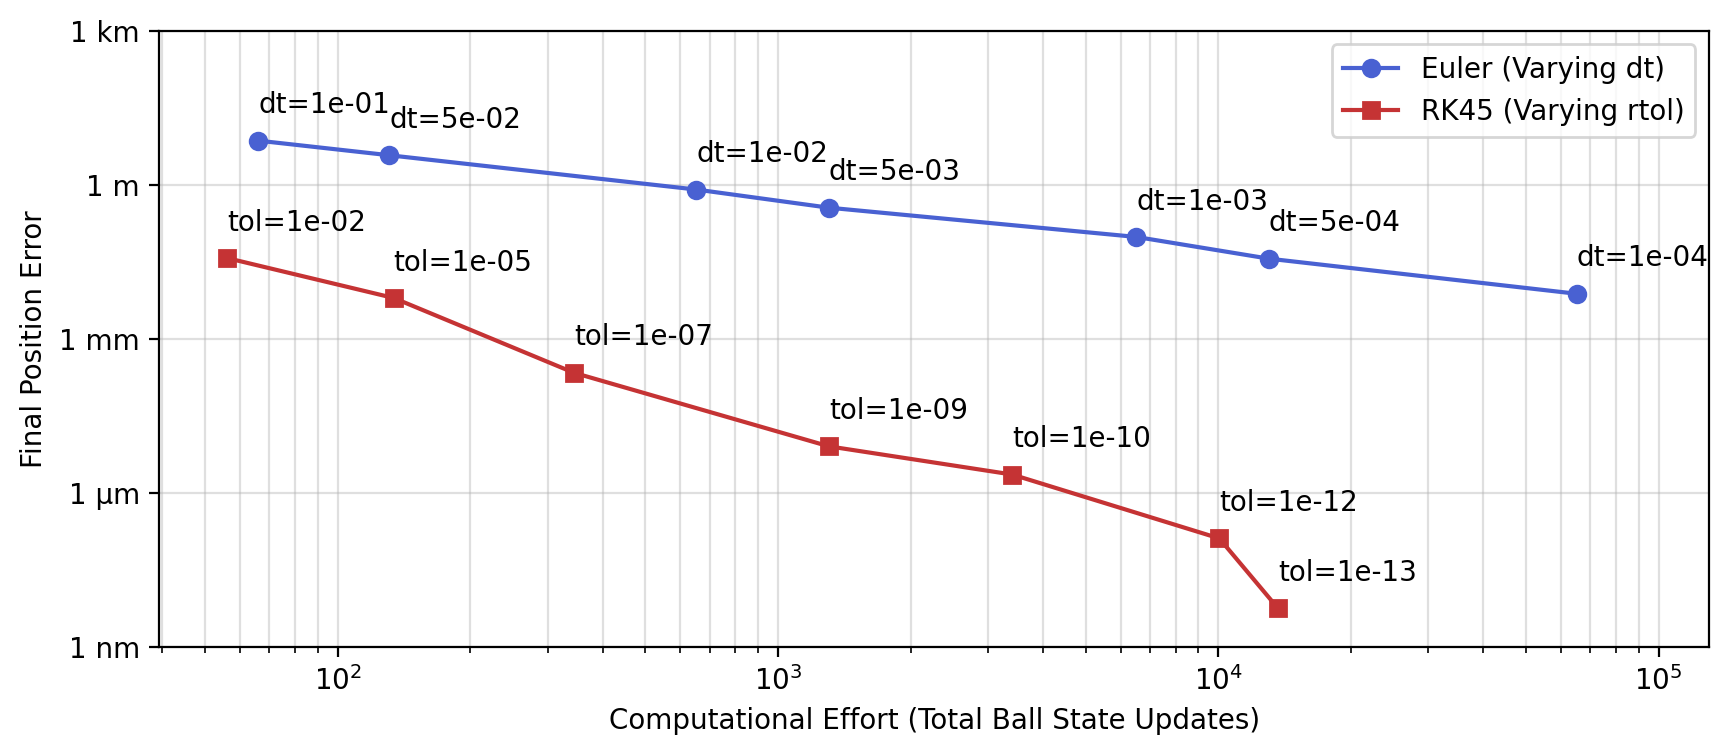

In [101]:
plot_convergence(*test_case)